# Phase 5 — Sparse vs Dense Layouts & Fusion Plan

Compare the TF-IDF and tabular matrices: shape, density, memory, and why a sparse horizontal stack is the right merge strategy.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
PROC = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def csr_nbytes(mat: sparse.spmatrix) -> int:
    mat = mat.tocsr()
    return int(mat.data.nbytes + mat.indices.nbytes + mat.indptr.nbytes)


def dense_nbytes(shape, dtype=np.float32) -> int:
    return int(np.prod(shape) * np.dtype(dtype).itemsize)

## 1. Load aligned matrices

In [2]:
X_text_train = sparse.load_npz(PROC / "X_text_train.npz").tocsr()
X_tab_train = sparse.load_npz(PROC / "X_tab_train.npz").tocsr()
X_text_test = sparse.load_npz(PROC / "X_text_test.npz").tocsr()
X_tab_test = sparse.load_npz(PROC / "X_tab_test.npz").tocsr()

assert X_text_train.shape[0] == X_tab_train.shape[0]
assert X_text_test.shape[0] == X_tab_test.shape[0]

summary = pd.DataFrame(
    [
        {
            "matrix": "text_train",
            "shape": str(X_text_train.shape),
            "density": X_text_train.nnz / np.prod(X_text_train.shape),
            "sparse_mb": csr_nbytes(X_text_train) / 1e6,
            "dense_f32_mb": dense_nbytes(X_text_train.shape) / 1e6,
        },
        {
            "matrix": "tab_train",
            "shape": str(X_tab_train.shape),
            "density": X_tab_train.nnz / np.prod(X_tab_train.shape),
            "sparse_mb": csr_nbytes(X_tab_train) / 1e6,
            "dense_f32_mb": dense_nbytes(X_tab_train.shape) / 1e6,
        },
        {
            "matrix": "text_test",
            "shape": str(X_text_test.shape),
            "density": X_text_test.nnz / np.prod(X_text_test.shape),
            "sparse_mb": csr_nbytes(X_text_test) / 1e6,
            "dense_f32_mb": dense_nbytes(X_text_test.shape) / 1e6,
        },
        {
            "matrix": "tab_test",
            "shape": str(X_tab_test.shape),
            "density": X_tab_test.nnz / np.prod(X_tab_test.shape),
            "sparse_mb": csr_nbytes(X_tab_test) / 1e6,
            "dense_f32_mb": dense_nbytes(X_tab_test.shape) / 1e6,
        },
    ]
)
summary.round(6)

,matrix,shape,density,sparse_mb,dense_f32_mb
0,text_train,"(264728, 2500)",0.001027,6.498940,2647.280000
1,tab_train,"(264728, 213)",0.028169,20.119332,225.548256
2,text_test,"(66183, 2500)",0.001023,1.618416,661.830000
3,tab_test,"(66183, 213)",0.028169,5.029912,56.387916


### What these numbers show

- **Text** is extremely sparse (~0.1% filled). Storing it dense would cost on the order of **gigabytes** for train alone.
- **Tabular** is denser (~2.8%) and narrower (213 cols). Sparse still helps, but the big win is on the TF-IDF side.
- Both blocks already share the same row count — required before any horizontal merge.

## 2. Visualize density and memory contrast

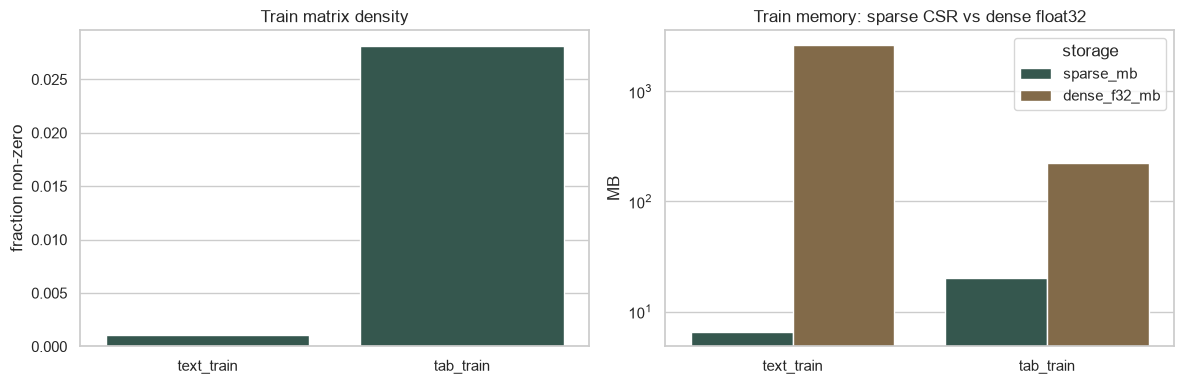

In [3]:
plot_df = summary[summary["matrix"].str.endswith("_train")].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=plot_df, x="matrix", y="density", color="#2f5d50", ax=axes[0])
axes[0].set_title("Train matrix density")
axes[0].set_ylabel("fraction non-zero")
axes[0].set_xlabel("")

mem = plot_df.melt(
    id_vars=["matrix"],
    value_vars=["sparse_mb", "dense_f32_mb"],
    var_name="storage",
    value_name="mb",
)
sns.barplot(data=mem, x="matrix", y="mb", hue="storage", ax=axes[1], palette=["#2f5d50", "#8c6b3f"])
axes[1].set_title("Train memory: sparse CSR vs dense float32")
axes[1].set_ylabel("MB")
axes[1].set_xlabel("")
axes[1].set_yscale("log")

plt.tight_layout()
fig.savefig(FIG_DIR / "05_sparse_vs_dense_memory.png", dpi=150)
plt.show()

### What this figure shows

Log-scaled memory makes the text gap obvious: dense TF-IDF is orders of magnitude heavier than CSR. That is why we never densify the text block before fusion.

## 3. Why naive concatenation fails (or hurts)

In [4]:
notes = []

# 1) numpy hstack needs dense arrays of compatible type/layout
try:
    np.hstack([X_text_train, X_tab_train])
    notes.append({"attempt": "np.hstack(sparse, sparse)", "result": "unexpected success"})
except Exception as exc:
    notes.append({"attempt": "np.hstack(sparse, sparse)", "result": type(exc).__name__, "detail": str(exc)[:160]})

# 2) densifying text is the dangerous path people try next
text_dense_gb = dense_nbytes(X_text_train.shape, np.float32) / 1e9
notes.append(
    {
        "attempt": "X_text_train.toarray() then concatenate",
        "result": "possible but costly",
        "detail": f"~{text_dense_gb:.2f} GB float32 for text train alone (before tabular)",
    }
)

# 3) correct approach estimate
fused_demo = sparse.hstack([X_text_train, X_tab_train], format="csr")
notes.append(
    {
        "attempt": "scipy.sparse.hstack([text, tab])",
        "result": "works",
        "detail": f"shape {fused_demo.shape}, sparse≈{csr_nbytes(fused_demo)/1e6:.1f} MB, density={fused_demo.nnz/np.prod(fused_demo.shape):.6f}",
    }
)

pd.DataFrame(notes)

,attempt,result,detail
0,"np.hstack(sparse, sparse)",unexpected success,NaN
1,X_text_train.toarray() then concatenate,possible but costly,~2.65 GB float32 for text train alone (before ...
2,"scipy.sparse.hstack([text, tab])",works,"shape (264728, 2713), sparse≈28.3 MB, density=..."


### What this experiment shows

`numpy` concatenation is the wrong API for SciPy sparse objects. Densifying text first “works” mathematically but blows past the project’s memory budget. `scipy.sparse.hstack` keeps both blocks compressed and produces one train matrix ready for logistic regression.

## 4. Fusion plan for Phase 6

In [5]:
plan = {
    "method": "scipy.sparse.hstack",
    "train_blocks": ["X_text_train.npz", "X_tab_train.npz"],
    "test_blocks": ["X_text_test.npz", "X_tab_test.npz"],
    "output_format": "csr",
    "expected_train_shape": [int(X_text_train.shape[0]), int(X_text_train.shape[1] + X_tab_train.shape[1])],
    "expected_test_shape": [int(X_text_test.shape[0]), int(X_text_test.shape[1] + X_tab_test.shape[1])],
    "feature_name_sources": ["tfidf_feature_names.csv", "tab_feature_names.csv"],
    "row_alignment": "split_ids.csv order already validated in Phase 4",
    "targets": ["y_train.npy", "y_test.npy"],
    "estimated_train_sparse_mb": round(csr_nbytes(fused_demo) / 1e6, 2),
    "do_not": [
        "np.hstack on sparse matrices",
        "toarray() on the TF-IDF block before merge",
        "refit vectorizer/preprocessor after split",
    ],
}

with open(PROC / "fusion_plan.json", "w", encoding="utf-8") as f:
    json.dump(plan, f, indent=2)

plan

{'method': 'scipy.sparse.hstack',
 'train_blocks': ['X_text_train.npz', 'X_tab_train.npz'],
 'test_blocks': ['X_text_test.npz', 'X_tab_test.npz'],
 'output_format': 'csr',
 'expected_train_shape': [264728, 2713],
 'expected_test_shape': [66183, 2713],
 'feature_name_sources': ['tfidf_feature_names.csv', 'tab_feature_names.csv'],
 'row_alignment': 'split_ids.csv order already validated in Phase 4',
 'targets': ['y_train.npy', 'y_test.npy'],
 'estimated_train_sparse_mb': 28.28,
 'do_not': ['np.hstack on sparse matrices',
  'toarray() on the TF-IDF block before merge',
  'refit vectorizer/preprocessor after split']}

## Phase 5 takeaways

- Text and tabular modalities differ sharply in density and memory profile.
- Dense concatenation of TF-IDF is the failure mode to avoid.
- Planned merge: `X_fused = hstack([X_text, X_tab])` in CSR form.
- Expected fused width: `2500 + 213 = 2713` features.
- Written plan: `data/processed/fusion_plan.json` · notes: [`docs/fusion-plan.md`](../docs/fusion-plan.md).